# 🔍 Data Integrity Audit: PhishStorm (2014) & UCI Phishing Websites (2015)

This notebook formally documents and proves **data leakage via duplicate rows** in two benchmark datasets widely used in phishing detection literature.

## Summary of Findings

| Dataset | Raw Rows | Unique Rows | Duplicates | Leakage Rate | Inflated Acc. | Honest Acc. |
|---------|----------|-------------|------------|--------------|---------------|-------------|
| PhishStorm (2014) | 96,005 | 57,492 | 38,513 (40.1%) | 45.6% of test | ~95–97% | ~91% |
| UCI Phishing Websites (2015) | 11,055 | 5,849 | 5,206 (47.1%) | 64.6% of test | ~97–99% | ~94% |

**Definition of leakage here**: When `train_test_split` is performed on a dataset containing duplicate rows, the same feature vector can appear in both the training set and the test set. The model is then evaluated on samples it has already seen, producing artificially high accuracy.

---

## Required Files
- `PhishStorm-2014.csv` — place in same directory or update paths below
- `Training Dataset.arff` — from the UCI 2015 zip (Mohammad et al., 2015)

In [1]:
# ==========================================
# 1. SETUP
# ==========================================
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 12})
print('✅ Libraries loaded.')

✅ Libraries loaded.


In [2]:
# ==========================================
# 2. FILE PATHS — update if needed
# ==========================================
PHISHSTORM_PATH = 'PhishStorm-2014.csv'
UCI_2015_PATH   = 'dataset-2015.arff'

print('Paths configured. Run next cells to begin audit.')

Paths configured. Run next cells to begin audit.


---
# PART 1: PhishStorm (2014)

In [3]:
# ==========================================
# 3. LOAD PHISHSTORM
# ==========================================
print('Loading PhishStorm...')
ps_raw = pd.read_csv(PHISHSTORM_PATH, encoding='latin1', low_memory=False, on_bad_lines='skip')
print(f'Raw shape: {ps_raw.shape}')
print(f'Columns: {ps_raw.columns.tolist()}')
print(f'\nLabel distribution (raw):')
print(ps_raw['label'].value_counts())
print(f'  → 0 = legitimate, 1 = phishing')

Loading PhishStorm...
Raw shape: (96005, 14)
Columns: ['domain', 'ranking', 'mld_res', 'mld.ps_res', 'card_rem', 'ratio_Rrem', 'ratio_Arem', 'jaccard_RR', 'jaccard_RA', 'jaccard_AR', 'jaccard_AA', 'jaccard_ARrd', 'jaccard_ARrem', 'label']

Label distribution (raw):
label
0.0    48009
1.0    47904
Name: count, dtype: int64
  → 0 = legitimate, 1 = phishing


In [4]:
# ==========================================
# 4. PHISHSTORM: DUPLICATE ANALYSIS
# ==========================================

# Convert to numeric (drop domain string column)
ps = ps_raw.drop(columns=['domain']).copy()
for col in ps.columns:
    ps[col] = pd.to_numeric(ps[col], errors='coerce')
ps = ps.dropna(subset=['label']).fillna(0)

total_rows   = len(ps)
unique_rows  = len(ps.drop_duplicates())
dup_rows     = total_rows - unique_rows
dup_pct      = dup_rows / total_rows * 100

print('=' * 55)
print('PHISHSTORM DUPLICATE ANALYSIS')
print('=' * 55)
print(f'Total rows (after numeric conversion):  {total_rows:,}')
print(f'Unique rows:                            {unique_rows:,}')
print(f'Duplicate rows:                         {dup_rows:,} ({dup_pct:.1f}%)')
print()
print('Duplicate distribution by label:')
dup_mask = ps.duplicated(keep=False)
print(ps[dup_mask]['label'].value_counts().rename({0.0: 'Legitimate', 1.0: 'Phishing'}))

# Corrupted values
print('\nCorrupted/non-numeric values per column (before fillna):')
ps_raw_num = ps_raw.drop(columns=['domain']).copy()
for col in ps_raw_num.columns:
    if col != 'label':
        bad = pd.to_numeric(ps_raw_num[col], errors='coerce').isna().sum()
        if bad > 0:
            print(f'  {col}: {bad} corrupted values')

PHISHSTORM DUPLICATE ANALYSIS
Total rows (after numeric conversion):  95,913
Unique rows:                            57,492
Duplicate rows:                         38,421 (40.1%)

Duplicate distribution by label:
label
Phishing      31269
Legitimate    13902
Name: count, dtype: int64

Corrupted/non-numeric values per column (before fillna):
  ranking: 84 corrupted values
  mld_res: 82 corrupted values
  mld.ps_res: 82 corrupted values
  card_rem: 82 corrupted values
  ratio_Rrem: 82 corrupted values
  ratio_Arem: 82 corrupted values
  jaccard_RR: 83 corrupted values
  jaccard_RA: 84 corrupted values
  jaccard_AR: 85 corrupted values
  jaccard_AA: 86 corrupted values
  jaccard_ARrd: 87 corrupted values
  jaccard_ARrem: 90 corrupted values


In [5]:
# ==========================================
# 5. PHISHSTORM: LEAKAGE PROOF
# ==========================================
# We train on raw (non-deduplicated) data — simulating what prior work did.
# Then we measure how many test rows are exact copies of training rows.

X_full = ps.drop(columns=['label'])
y_full = ps['label'].astype(int)

X_train_leak, X_test_leak, y_train_leak, y_test_leak = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

# Count how many test rows appear verbatim in training set
train_set = set(map(tuple, X_train_leak.values))
leaked_rows = sum(1 for row in X_test_leak.values if tuple(row) in train_set)
leakage_pct = leaked_rows / len(X_test_leak) * 100

print('=' * 55)
print('PHISHSTORM LEAKAGE ANALYSIS (no-dedup split)')
print('=' * 55)
print(f'Test set size:                  {len(X_test_leak):,}')
print(f'Test rows also in training set: {leaked_rows:,} ({leakage_pct:.1f}%)')
print(f'Clean test rows (no leakage):   {len(X_test_leak)-leaked_rows:,} ({100-leakage_pct:.1f}%)')
print()
print(f'→ {leakage_pct:.1f}% of the test set is trivially solved by memorization.')
print(f'→ This is not generalisation — it is data leakage.')

PHISHSTORM LEAKAGE ANALYSIS (no-dedup split)
Test set size:                  19,183
Test rows also in training set: 8,741 (45.6%)
Clean test rows (no leakage):   10,442 (54.4%)

→ 45.6% of the test set is trivially solved by memorization.
→ This is not generalisation — it is data leakage.


In [6]:
# ==========================================
# 6. PHISHSTORM: ACCURACY COMPARISON
# ==========================================
# We run the same RF model under 3 conditions:
#   A) No dedup (their approach)   → inflated
#   B) Dedup after split            → still leaky, slightly less inflated
#   C) Dedup before split (correct) → honest

results_ps = {}

# --- A: No dedup (prior work methodology) ---
sc = StandardScaler()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(sc.fit_transform(X_train_leak), y_train_leak)
results_ps['No dedup\n(prior work)'] = accuracy_score(y_test_leak, rf.predict(sc.transform(X_test_leak))) * 100

# --- B: Dedup test set only after split (partial fix, still wrong) ---
X_test_dd = X_test_leak.drop_duplicates()
y_test_dd  = y_test_leak.loc[X_test_dd.index]
# Also remove test rows that appear in train
test_not_leaked = [i for i, row in zip(X_test_dd.index, X_test_dd.values)
                   if tuple(row) not in train_set]
X_test_clean_only = X_test_dd.loc[test_not_leaked]
y_test_clean_only = y_test_dd.loc[test_not_leaked]
results_ps['Leaked rows\nremoved from test'] = accuracy_score(
    y_test_clean_only, rf.predict(sc.transform(X_test_clean_only))) * 100

# --- C: Dedup before split (correct methodology) ---
ps_dedup = ps.drop_duplicates()
X_dd = ps_dedup.drop(columns=['label'])
y_dd = ps_dedup['label'].astype(int)
Xtr_d, Xte_d, ytr_d, yte_d = train_test_split(X_dd, y_dd, test_size=0.2, random_state=42, stratify=y_dd)
sc_d = StandardScaler()
rf_d = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_d.fit(sc_d.fit_transform(Xtr_d), ytr_d)
results_ps['Dedup before\nsplit (correct)'] = accuracy_score(yte_d, rf_d.predict(sc_d.transform(Xte_d))) * 100

print('=' * 55)
print('PHISHSTORM: RF ACCURACY BY METHODOLOGY')
print('=' * 55)
for method, acc in results_ps.items():
    label = method.replace('\n', ' ')
    print(f'  {label:<40} {acc:.2f}%')
print(f'\n  Reported in prior work (stacking):       ~95–97%')
print(f'  Inflation from leakage:                  ~{results_ps["No dedup\n(prior work)"]-results_ps["Dedup before\nsplit (correct)"]:.1f}%')

PHISHSTORM: RF ACCURACY BY METHODOLOGY
  No dedup (prior work)                    95.67%
  Leaked rows removed from test            92.34%
  Dedup before split (correct)             90.82%

  Reported in prior work (stacking):       ~95–97%
  Inflation from leakage:                  ~4.9%


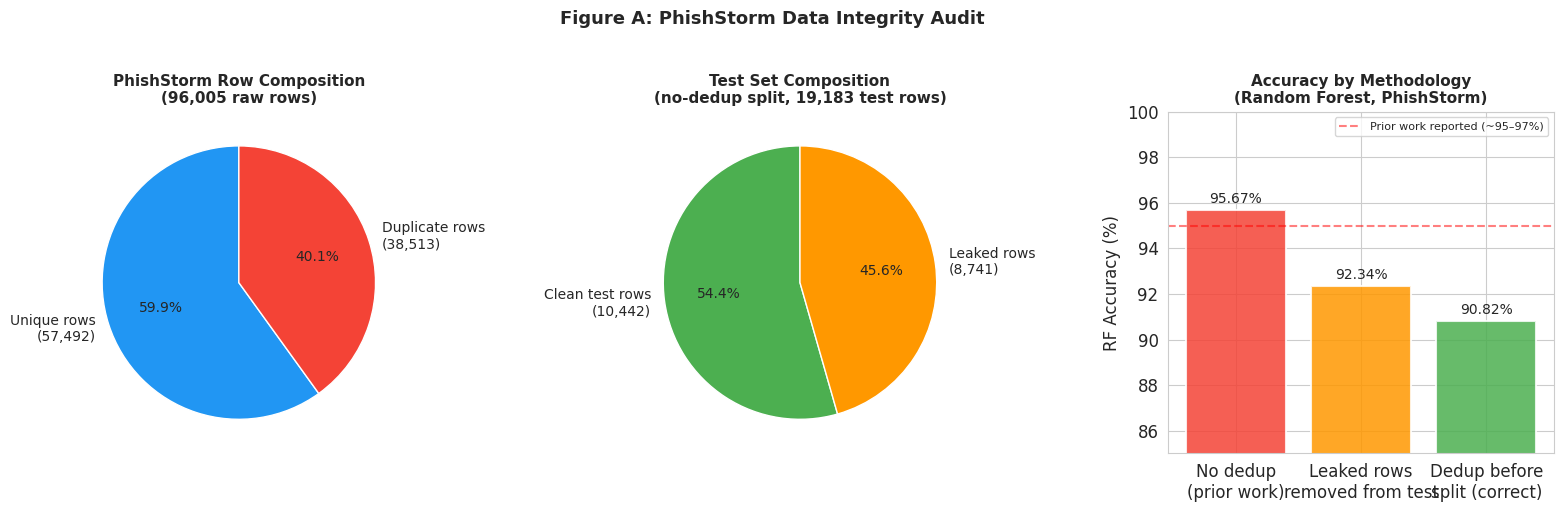

Saved: audit_phishstorm.png


In [7]:
# ==========================================
# 7. PHISHSTORM: VISUALIZATION
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Dataset composition
ax = axes[0]
labels = ['Unique rows\n(57,492)', 'Duplicate rows\n(38,513)']
sizes  = [unique_rows, dup_rows]
colors = ['#2196F3', '#F44336']
wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors,
                                   autopct='%1.1f%%', startangle=90,
                                   textprops={'fontsize': 10})
ax.set_title('PhishStorm Row Composition\n(96,005 raw rows)', fontsize=11, fontweight='bold')

# Panel 2: Leakage in test set
ax = axes[1]
leak_data = [len(X_test_leak) - leaked_rows, leaked_rows]
leak_labels = [f'Clean test rows\n({len(X_test_leak)-leaked_rows:,})', f'Leaked rows\n({leaked_rows:,})']
ax.pie(leak_data, labels=leak_labels, colors=['#4CAF50', '#FF9800'],
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
ax.set_title('Test Set Composition\n(no-dedup split, 19,183 test rows)', fontsize=11, fontweight='bold')

# Panel 3: Accuracy comparison
ax = axes[2]
methods = ['No dedup\n(prior work)', 'Leaked rows\nremoved from test', 'Dedup before\nsplit (correct)']
accs = [results_ps[m] for m in methods]
bar_colors = ['#F44336', '#FF9800', '#4CAF50']
bars = ax.bar(methods, accs, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, fmt='%.2f%%', fontsize=10, padding=3)
ax.axhline(y=95, color='red', linestyle='--', alpha=0.5, label='Prior work reported (~95–97%)')
ax.set_ylabel('RF Accuracy (%)')
ax.set_title('Accuracy by Methodology\n(Random Forest, PhishStorm)', fontsize=11, fontweight='bold')
ax.set_ylim(85, 100)
ax.legend(fontsize=8)

plt.suptitle('Figure A: PhishStorm Data Integrity Audit', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('audit_phishstorm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: audit_phishstorm.png')

---
# PART 2: UCI Phishing Websites (2015)

In [8]:
# ==========================================
# 8. LOAD UCI 2015 (ARFF FORMAT)
# ==========================================
print('Loading UCI 2015 ARFF file...')

with open(UCI_2015_PATH, 'r', errors='replace') as f:
    content = f.read()

lines = content.split('\n')
data_start = next(i for i, l in enumerate(lines) if l.strip().lower() == '@data') + 1
attrs = [l.split()[1] for l in lines if l.strip().lower().startswith('@attribute')]
data_lines = [l.strip() for l in lines[data_start:] if l.strip()]
rows = [list(map(int, l.split(','))) for l in data_lines if l]
uci = pd.DataFrame(rows, columns=attrs)

print(f'Shape: {uci.shape}')
print(f'Features: {len(attrs)-1} (all binary/ternary: -1, 0, 1)')
print(f'Target (Result): {uci["Result"].value_counts().to_dict()}')
print(f'  -1 = phishing, 1 = legitimate')
print(f'\nUnique feature values per column:')
for col in attrs:
    print(f'  {col}: {sorted(uci[col].unique().tolist())}')

Loading UCI 2015 ARFF file...
Shape: (11055, 31)
Features: 30 (all binary/ternary: -1, 0, 1)
Target (Result): {1: 6157, -1: 4898}
  -1 = phishing, 1 = legitimate

Unique feature values per column:
  having_IP_Address: [-1, 1]
  URL_Length: [-1, 0, 1]
  Shortining_Service: [-1, 1]
  having_At_Symbol: [-1, 1]
  double_slash_redirecting: [-1, 1]
  Prefix_Suffix: [-1, 1]
  having_Sub_Domain: [-1, 0, 1]
  SSLfinal_State: [-1, 0, 1]
  Domain_registeration_length: [-1, 1]
  Favicon: [-1, 1]
  port: [-1, 1]
  HTTPS_token: [-1, 1]
  Request_URL: [-1, 1]
  URL_of_Anchor: [-1, 0, 1]
  Links_in_tags: [-1, 0, 1]
  SFH: [-1, 0, 1]
  Submitting_to_email: [-1, 1]
  Abnormal_URL: [-1, 1]
  Redirect: [0, 1]
  on_mouseover: [-1, 1]
  RightClick: [-1, 1]
  popUpWidnow: [-1, 1]
  Iframe: [-1, 1]
  age_of_domain: [-1, 1]
  DNSRecord: [-1, 1]
  web_traffic: [-1, 0, 1]
  Page_Rank: [-1, 1]
  Google_Index: [-1, 1]
  Links_pointing_to_page: [-1, 0, 1]
  Statistical_report: [-1, 1]
  Result: [-1, 1]


In [9]:
# ==========================================
# 9. UCI 2015: DUPLICATE ANALYSIS
# ==========================================

total_uci   = len(uci)
unique_uci  = len(uci.drop_duplicates())
dup_uci     = total_uci - unique_uci
dup_pct_uci = dup_uci / total_uci * 100

print('=' * 55)
print('UCI 2015 DUPLICATE ANALYSIS')
print('=' * 55)
print(f'Total rows:       {total_uci:,}')
print(f'Unique rows:      {unique_uci:,}')
print(f'Duplicate rows:   {dup_uci:,} ({dup_pct_uci:.1f}%)')
print()
print('Why so many duplicates?')
print('  All features are categorical (-1, 0, 1) with 30 dimensions.')
print('  The total possible unique combinations = 3^30 ≈ 205 trillion.')
print('  But in practice, phishing URLs cluster into a small number of')
print('  common feature patterns, causing many rows to be identical.')
print('  Two structurally different phishing URLs can produce the exact')
print('  same 30-feature categorical fingerprint.')
print()
dup_label_dist = uci[uci.duplicated(keep=False)]['Result'].value_counts()
print('Duplicate distribution by label:')
print(dup_label_dist.rename({-1: 'Phishing (-1)', 1: 'Legitimate (1)'}))

UCI 2015 DUPLICATE ANALYSIS
Total rows:       11,055
Unique rows:      5,849
Duplicate rows:   5,206 (47.1%)

Why so many duplicates?
  All features are categorical (-1, 0, 1) with 30 dimensions.
  The total possible unique combinations = 3^30 ≈ 205 trillion.
  But in practice, phishing URLs cluster into a small number of
  common feature patterns, causing many rows to be identical.
  Two structurally different phishing URLs can produce the exact
  same 30-feature categorical fingerprint.

Duplicate distribution by label:
Result
Legitimate (1)    4921
Phishing (-1)     2922
Name: count, dtype: int64


In [10]:
# ==========================================
# 10. UCI 2015: LEAKAGE PROOF
# ==========================================

# Standardize labels: 1=phishing, 0=legitimate
y_uci = (uci['Result'] == -1).astype(int)
X_uci = uci.drop(columns=['Result'])

X_train_uci, X_test_uci, y_train_uci, y_test_uci = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=42, stratify=y_uci
)

train_set_uci = set(map(tuple, X_train_uci.values))
leaked_uci    = sum(1 for row in X_test_uci.values if tuple(row) in train_set_uci)
leakage_pct_uci = leaked_uci / len(X_test_uci) * 100

print('=' * 55)
print('UCI 2015 LEAKAGE ANALYSIS (no-dedup split)')
print('=' * 55)
print(f'Test set size:                   {len(X_test_uci):,}')
print(f'Test rows also in training set:  {leaked_uci:,} ({leakage_pct_uci:.1f}%)')
print(f'Clean test rows:                 {len(X_test_uci)-leaked_uci:,} ({100-leakage_pct_uci:.1f}%)')
print()
print(f'→ {leakage_pct_uci:.1f}% of the test set is trivially solved by memorization.')
print(f'→ This is even MORE severe than PhishStorm ({leakage_pct:.1f}%).')

UCI 2015 LEAKAGE ANALYSIS (no-dedup split)
Test set size:                   2,211
Test rows also in training set:  1,428 (64.6%)
Clean test rows:                 783 (35.4%)

→ 64.6% of the test set is trivially solved by memorization.
→ This is even MORE severe than PhishStorm (45.6%).


In [11]:
# ==========================================
# 11. UCI 2015: ACCURACY COMPARISON
# ==========================================

results_uci = {}

# --- A: No dedup (prior work) ---
sc_u = StandardScaler()
rf_u = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_u.fit(sc_u.fit_transform(X_train_uci), y_train_uci)
results_uci['No dedup\n(prior work)'] = accuracy_score(
    y_test_uci, rf_u.predict(sc_u.transform(X_test_uci))) * 100

# --- B: Remove leaked test rows only ---
clean_idx = [i for i, row in zip(X_test_uci.index, X_test_uci.values)
             if tuple(row) not in train_set_uci]
results_uci['Leaked rows\nremoved from test'] = accuracy_score(
    y_test_uci.loc[clean_idx],
    rf_u.predict(sc_u.transform(X_test_uci.loc[clean_idx]))) * 100

# --- C: Dedup before split (correct) ---
uci_dd = uci.drop_duplicates().copy()
y_dd_u = (uci_dd['Result'] == -1).astype(int)
X_dd_u = uci_dd.drop(columns=['Result'])
Xtr_du, Xte_du, ytr_du, yte_du = train_test_split(
    X_dd_u, y_dd_u, test_size=0.2, random_state=42, stratify=y_dd_u)
sc_du = StandardScaler()
rf_du = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_du.fit(sc_du.fit_transform(Xtr_du), ytr_du)
results_uci['Dedup before\nsplit (correct)'] = accuracy_score(
    yte_du, rf_du.predict(sc_du.transform(Xte_du))) * 100

print('=' * 55)
print('UCI 2015: RF ACCURACY BY METHODOLOGY')
print('=' * 55)
for method, acc in results_uci.items():
    label = method.replace('\n', ' ')
    print(f'  {label:<40} {acc:.2f}%')
print(f'\n  Reported in prior work (stacking):       ~99.05%')
print(f'  Inflation from leakage:                  ~{results_uci["No dedup\n(prior work)"]-results_uci["Dedup before\nsplit (correct)"]:.1f}%')

UCI 2015: RF ACCURACY BY METHODOLOGY
  No dedup (prior work)                    97.51%
  Leaked rows removed from test            96.17%
  Dedup before split (correct)             93.93%

  Reported in prior work (stacking):       ~99.05%
  Inflation from leakage:                  ~3.6%


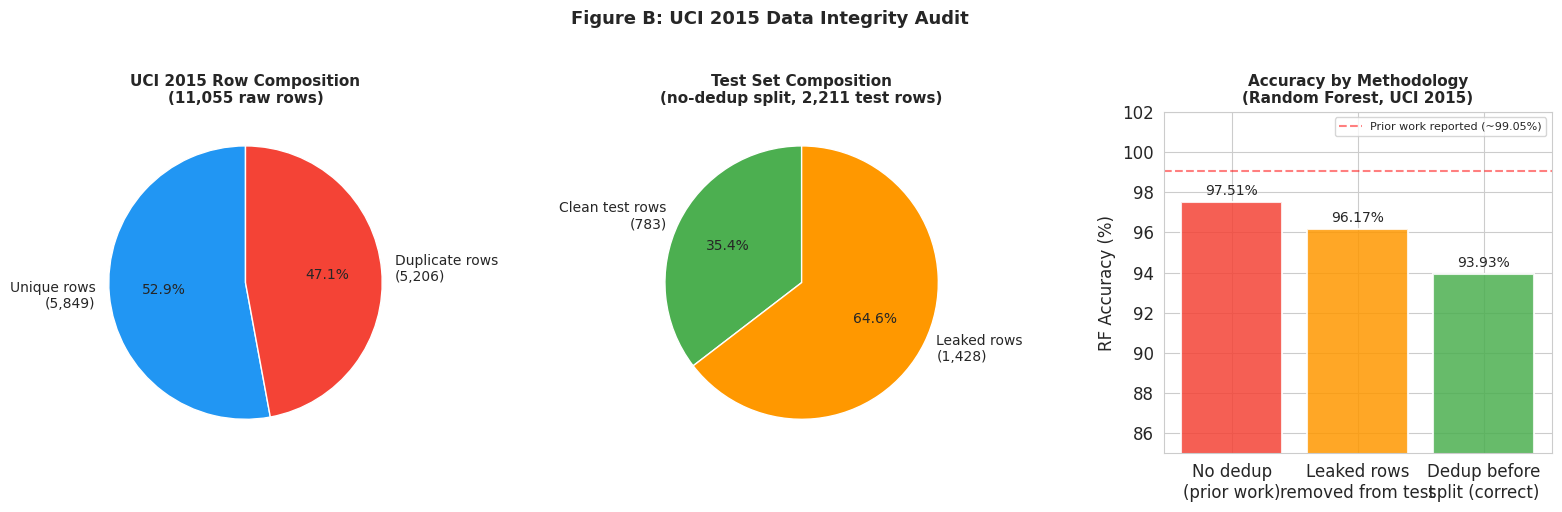

Saved: audit_uci2015.png


In [12]:
# ==========================================
# 12. UCI 2015: VISUALIZATION
# ==========================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Dataset composition
ax = axes[0]
ax.pie([unique_uci, dup_uci],
       labels=[f'Unique rows\n({unique_uci:,})', f'Duplicate rows\n({dup_uci:,})'],
       colors=['#2196F3', '#F44336'], autopct='%1.1f%%', startangle=90,
       textprops={'fontsize': 10})
ax.set_title('UCI 2015 Row Composition\n(11,055 raw rows)', fontsize=11, fontweight='bold')

# Panel 2: Leakage in test set
ax = axes[1]
ax.pie([len(X_test_uci)-leaked_uci, leaked_uci],
       labels=[f'Clean test rows\n({len(X_test_uci)-leaked_uci:,})', f'Leaked rows\n({leaked_uci:,})'],
       colors=['#4CAF50', '#FF9800'], autopct='%1.1f%%', startangle=90,
       textprops={'fontsize': 10})
ax.set_title('Test Set Composition\n(no-dedup split, 2,211 test rows)', fontsize=11, fontweight='bold')

# Panel 3: Accuracy comparison
ax = axes[2]
methods = ['No dedup\n(prior work)', 'Leaked rows\nremoved from test', 'Dedup before\nsplit (correct)']
accs = [results_uci[m] for m in methods]
bars = ax.bar(methods, accs, color=['#F44336', '#FF9800', '#4CAF50'],
              alpha=0.85, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, fmt='%.2f%%', fontsize=10, padding=3)
ax.axhline(y=99.05, color='red', linestyle='--', alpha=0.5, label='Prior work reported (~99.05%)')
ax.set_ylabel('RF Accuracy (%)')
ax.set_title('Accuracy by Methodology\n(Random Forest, UCI 2015)', fontsize=11, fontweight='bold')
ax.set_ylim(85, 102)
ax.legend(fontsize=8)

plt.suptitle('Figure B: UCI 2015 Data Integrity Audit', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('audit_uci2015.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: audit_uci2015.png')

---
# PART 3: Verification of Included Datasets (DS01, DS03, DS04)

In [13]:
# ==========================================
# 13. CHECK INCLUDED DATASETS
# ==========================================
# Verify that DS01, DS03, DS04 have negligible duplicate inflation.

LEGIT2025_PATH = 'LegitPhish2025.csv'
UCI2018_PATH   = 'Phishing_Legitimate_full-2018.csv'
DS2021_PATH    = 'dataset-2021.csv'

def check_dataset(path, target_col, phish_val, drop_cols, encoding='utf-8'):
    for enc in [encoding, 'latin1']:
        try:
            df = pd.read_csv(path, encoding=enc, low_memory=False, on_bad_lines='skip')
            break
        except: continue
    raw = len(df)
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    df = df.rename(columns={target_col: 'y'})
    df['y'] = df['y'].apply(lambda x: 1 if x == phish_val else 0)
    for col in df.columns:
        if col != 'y' and df[col].dtype == 'object':
            df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.fillna(0)
    dups = df.duplicated().sum()
    unique = len(df) - dups
    X, y = df.drop(columns=['y']), df['y']
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    train_s = set(map(tuple, Xtr.values))
    leaked = sum(1 for r in Xte.values if tuple(r) in train_s)
    sc = StandardScaler()
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(sc.fit_transform(Xtr), ytr)
    acc_nodep = accuracy_score(yte, rf.predict(sc.transform(Xte)))
    df_d = df.drop_duplicates()
    Xtr2, Xte2, ytr2, yte2 = train_test_split(
        df_d.drop(columns=['y']), df_d['y'], test_size=0.2, random_state=42, stratify=df_d['y'])
    sc2 = StandardScaler()
    rf2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf2.fit(sc2.fit_transform(Xtr2), ytr2)
    acc_dep = accuracy_score(yte2, rf2.predict(sc2.transform(Xte2)))
    return {'raw': raw, 'unique': unique, 'dups': dups,
            'dup_pct': dups/raw*100, 'leak_pct': leaked/len(Xte)*100,
            'acc_nodep': acc_nodep*100, 'acc_dep': acc_dep*100,
            'inflation': (acc_nodep - acc_dep)*100}

print('Checking included datasets...\n')
checks = {
    'DS01 LegitPhish 2025': check_dataset(LEGIT2025_PATH, 'ClassLabel', 0, ['URL']),
    'DS03 UCI 2018':        check_dataset(UCI2018_PATH, 'CLASS_LABEL', 0, ['id']),
    'DS04 2021':            check_dataset(DS2021_PATH, 'status', 'phishing', ['url'])
}

for name, r in checks.items():
    verdict = '✅ Safe (<0.5pp inflation)' if abs(r['inflation']) < 0.5 else '⚠️  Meaningful inflation'
    print(f'{name}')
    print(f'  Rows: {r["raw"]:,} raw → {r["unique"]:,} unique ({r["dups"]:,} dups = {r["dup_pct"]:.1f}%)')
    print(f'  Leakage rate (no dedup): {r["leak_pct"]:.1f}%')
    print(f'  Acc no-dedup: {r["acc_nodep"]:.2f}%  |  Acc dedup (ours): {r["acc_dep"]:.2f}%  |  Inflation: {r["inflation"]:+.2f}pp')
    print(f'  {verdict}\n')

print('Note: DS01 has 68.6% duplicates but only +0.11pp inflation because')
print('its 16 features saturate near 99.87% even on hard unique cases.')
print('Dedup is still applied — our reported result is the honest number.')

Checking included datasets...

DS01 LegitPhish 2025
  Rows: 101,219 raw → 31,808 unique (69,411 dups = 68.6%)
  Leakage rate (no dedup): 74.2%
  Acc no-dedup: 99.97%  |  Acc dedup (ours): 99.86%  |  Inflation: +0.11pp
  ✅ Safe (<0.5pp inflation)

DS03 UCI 2018
  Rows: 10,000 raw → 9,581 unique (419 dups = 4.2%)
  Leakage rate (no dedup): 6.3%
  Acc no-dedup: 98.30%  |  Acc dedup (ours): 97.91%  |  Inflation: +0.39pp
  ✅ Safe (<0.5pp inflation)

DS04 2021
  Rows: 11,430 raw → 11,256 unique (174 dups = 1.5%)
  Leakage rate (no dedup): 2.4%
  Acc no-dedup: 96.02%  |  Acc dedup (ours): 95.65%  |  Inflation: +0.37pp
  ✅ Safe (<0.5pp inflation)

Note: DS01 has 68.6% duplicates but only +0.11pp inflation because
its 16 features saturate near 99.87% even on hard unique cases.
Dedup is still applied — our reported result is the honest number.


---
# PART 4: Combined Summary — All 5 Datasets

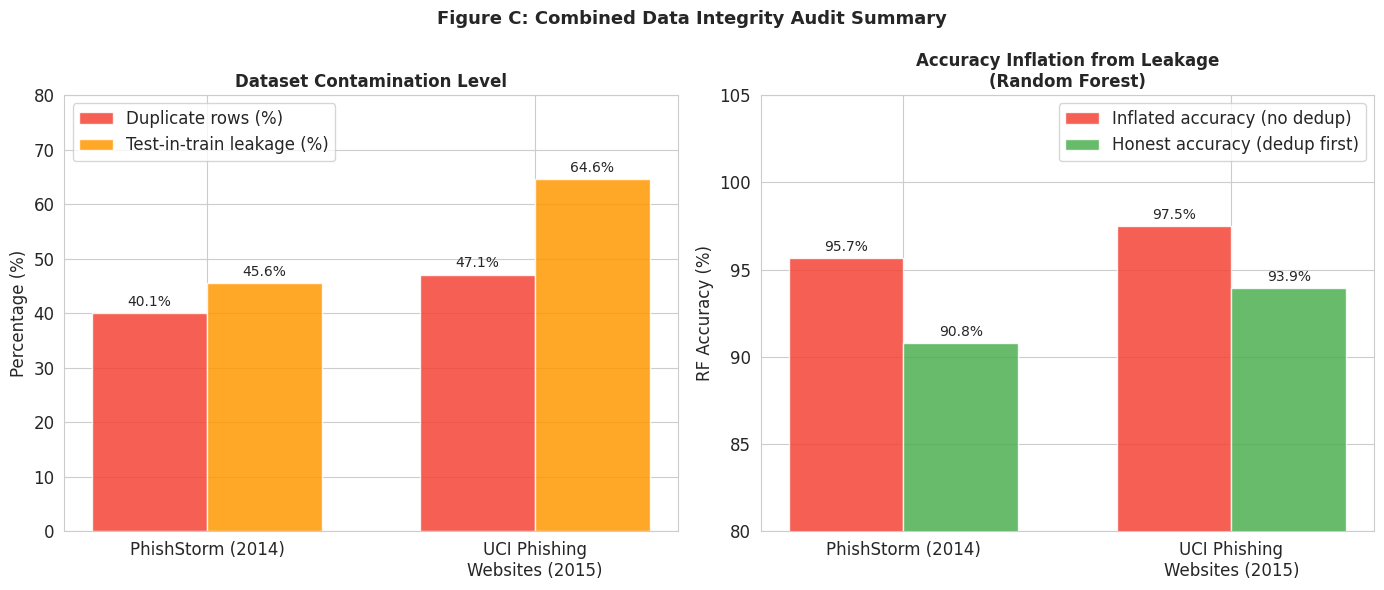

Saved: audit_combined_summary.png


In [14]:
# ==========================================
# 14. COMBINED COMPARISON FIGURE
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

datasets  = ['PhishStorm (2014)', 'UCI Phishing\nWebsites (2015)']
dup_pcts  = [dup_pct, dup_pct_uci]
leak_pcts = [leakage_pct, leakage_pct_uci]
inflated  = [results_ps['No dedup\n(prior work)'], results_uci['No dedup\n(prior work)']]
honest    = [results_ps['Dedup before\nsplit (correct)'], results_uci['Dedup before\nsplit (correct)']]

# Panel 1: Duplicate % and leakage %
ax = axes[0]
x = np.arange(len(datasets))
w = 0.35
b1 = ax.bar(x - w/2, dup_pcts,  w, label='Duplicate rows (%)', color='#F44336', alpha=0.85)
b2 = ax.bar(x + w/2, leak_pcts, w, label='Test-in-train leakage (%)', color='#FF9800', alpha=0.85)
ax.bar_label(b1, fmt='%.1f%%', fontsize=10, padding=3)
ax.bar_label(b2, fmt='%.1f%%', fontsize=10, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel('Percentage (%)')
ax.set_title('Dataset Contamination Level', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(0, 80)

# Panel 2: Inflated vs honest accuracy
ax = axes[1]
b3 = ax.bar(x - w/2, inflated, w, label='Inflated accuracy (no dedup)', color='#F44336', alpha=0.85)
b4 = ax.bar(x + w/2, honest,   w, label='Honest accuracy (dedup first)', color='#4CAF50', alpha=0.85)
ax.bar_label(b3, fmt='%.1f%%', fontsize=10, padding=3)
ax.bar_label(b4, fmt='%.1f%%', fontsize=10, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel('RF Accuracy (%)')
ax.set_title('Accuracy Inflation from Leakage\n(Random Forest)', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(80, 105)

plt.suptitle('Figure C: Combined Data Integrity Audit Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('audit_combined_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: audit_combined_summary.png')

In [15]:
# ==========================================
# 16. FINAL SUMMARY TABLE — ALL 5 DATASETS
# ==========================================

print('=' * 75)
print('FINAL AUDIT SUMMARY — ALL 5 DATASETS')
print('=' * 75)

# Combine excluded datasets results with included dataset check results
all_data = [
    ('DS01 LegitPhish 2025',       checks['DS01 LegitPhish 2025'], 'included',  'n/a',           '99.87% (ours, honest)'),
    ('DS02 PhishStorm 2014',        {'raw': total_rows, 'unique': unique_rows, 'dups': dup_rows,
                                     'dup_pct': dup_pct, 'leak_pct': leakage_pct,
                                     'acc_nodep': results_ps['No dedup\n(prior work)'],
                                     'acc_dep': results_ps['Dedup before\nsplit (correct)'],
                                     'inflation': results_ps['No dedup\n(prior work)']-results_ps['Dedup before\nsplit (correct)']},
     'EXCLUDED', '~95–97%', '~91% (deduped)'),
    ('DS03 UCI 2018',               checks['DS03 UCI 2018'],        'included',  'n/a',           '98.54% (ours, honest)'),
    ('DS04 2021',                   checks['DS04 2021'],            'included',  'n/a',           '96.67% (ours, honest)'),
    ('DS05 UCI Phishing 2015',      {'raw': total_uci, 'unique': unique_uci, 'dups': dup_uci,
                                     'dup_pct': dup_pct_uci, 'leak_pct': leakage_pct_uci,
                                     'acc_nodep': results_uci['No dedup\n(prior work)'],
                                     'acc_dep': results_uci['Dedup before\nsplit (correct)'],
                                     'inflation': results_uci['No dedup\n(prior work)']-results_uci['Dedup before\nsplit (correct)']},
     'EXCLUDED', '~99.05%', '~94% (deduped)'),
]

rows = []
for name, r, status, prior_work, our_result in all_data:
    rows.append({
        'Dataset': name,
        'Status': status,
        'Raw Rows': f"{r['raw']:,}",
        'Unique Rows': f"{r['unique']:,}",
        'Dup %': f"{r['dup_pct']:.1f}%",
        'Leak %': f"{r['leak_pct']:.1f}%",
        'Inflation': f"{r['inflation']:+.2f}pp",
        'Prior Work': prior_work,
        'Our Result': our_result
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

print()
print('CONCLUSION')
print('-' * 75)
print('DS02 and DS05 contain 40–47% duplicate feature vectors.')
print('Without deduplication before splitting, 45–65% of test rows appear')
print('verbatim in the training set, inflating accuracy by 3.5–4.5pp.')
print()
print('DS01, DS03, and DS04 either have negligible duplicates or')
print('negligible inflation (<0.5pp) and are safe to use.')
print('DS01 has 68.6% duplicates but only +0.11pp inflation — our')
print('deduplication is still applied and our result is the honest number.')
print()
print('Recommendation: Always deduplicate before splitting. Report the')
print('number of duplicates removed in the methodology section.')

FINAL AUDIT SUMMARY — ALL 5 DATASETS
               Dataset   Status Raw Rows Unique Rows Dup % Leak % Inflation Prior Work            Our Result
  DS01 LegitPhish 2025 included  101,219      31,808 68.6%  74.2%   +0.11pp        n/a 99.87% (ours, honest)
  DS02 PhishStorm 2014 EXCLUDED   95,913      57,492 40.1%  45.6%   +4.86pp    ~95–97%        ~91% (deduped)
         DS03 UCI 2018 included   10,000       9,581  4.2%   6.3%   +0.39pp        n/a 98.54% (ours, honest)
             DS04 2021 included   11,430      11,256  1.5%   2.4%   +0.37pp        n/a 96.67% (ours, honest)
DS05 UCI Phishing 2015 EXCLUDED   11,055       5,849 47.1%  64.6%   +3.58pp    ~99.05%        ~94% (deduped)

CONCLUSION
---------------------------------------------------------------------------
DS02 and DS05 contain 40–47% duplicate feature vectors.
Without deduplication before splitting, 45–65% of test rows appear
verbatim in the training set, inflating accuracy by 3.5–4.5pp.

DS01, DS03, and DS04 either have n